In [18]:
# ============================================
# Phase 2: Dataset Understanding
# AI Personal Finance Analyzer
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# load cleaned data
df = pd.read_csv('/Users/aadesh/finance-analyzer/data/processed/transactions_clean.csv')

# First look
print("shape of dataset:")
print(df.shape)

print("\ncolumn names:")
print(df.columns.tolist())

print("\nfirst 5 rows:")
df.head()

(58213, 13)
shape of dataset:
(58213, 13)

column names:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'balance_diff_orig', 'balance_diff_dest', 'orig_balance_zero', 'dest_balance_zero', 'amount_to_balance_ratio']

first 5 rows:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_orig,balance_diff_dest,orig_balance_zero,dest_balance_zero,amount_to_balance_ratio
0,141,3,9089.15,36375.0,27285.85,0.00,0.00,0,9089.15,0.00,0,1,0.249874
1,39,0,46702.66,1403541.1,1450243.76,3249011.68,3202309.03,0,-46702.66,-46702.65,0,0,0.033275
2,103,1,1254092.10,1254092.1,0.00,0.00,1254092.10,1,1254092.10,1254092.10,1,1,1.000000
3,404,3,13511.09,49827.0,36315.91,0.00,0.00,0,13511.09,0.00,0,1,0.271160
4,308,1,24681.51,429568.0,404886.49,271223.66,295905.16,0,24681.51,24681.50,0,0,0.057457


In [19]:
# ============================================
# Deep dive into the dataset
# ============================================

# check data types and missing values
print("data types and non-null counts:")
print(df.info())

print("\nmissing values per column:")
print(df.isnull().sum())

print("\nbasic statistics:")
df.describe()

data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 58213 entries, 0 to 58212
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   step                     58213 non-null  int64  
 1   type                     58213 non-null  int64  
 2   amount                   58213 non-null  float64
 3   oldbalanceOrg            58213 non-null  float64
 4   newbalanceOrig           58213 non-null  float64
 5   oldbalanceDest           58213 non-null  float64
 6   newbalanceDest           58213 non-null  float64
 7   isFraud                  58213 non-null  int64  
 8   balance_diff_orig        58213 non-null  float64
 9   balance_diff_dest        58213 non-null  float64
 10  orig_balance_zero        58213 non-null  int64  
 11  dest_balance_zero        58213 non-null  int64  
 12  amount_to_balance_ratio  58213 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 5.8 MB
None

miss

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff_orig,balance_diff_dest,orig_balance_zero,dest_balance_zero,amount_to_balance_ratio
count,58213.000000,58213.000000,5.821300e+04,5.821300e+04,5.821300e+04,5.821300e+04,5.821300e+04,58213.000000,5.821300e+04,5.821300e+04,58213.000000,58213.000000,58213.000000
mean,260.937832,1.834659,3.622564e+05,9.210085e+05,7.348422e+05,1.012553e+06,1.225120e+06,0.141085,1.861663e+05,2.125671e+05,0.627145,0.458918,65.085801
std,161.216473,1.397298,1.165412e+06,2.939178e+06,2.747353e+06,3.386217e+06,3.709431e+06,0.348113,1.041631e+06,1.058244e+06,0.483568,0.498314,2357.864999
min,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.225177e+06,-1.244636e+06,0.000000,0.000000,0.000000
25%,157.000000,1.000000,1.628009e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,253.000000,1.000000,9.659384e+04,2.263200e+04,0.000000e+00,6.442243e+04,1.894753e+05,0.000000,4.680000e+02,0.000000e+00,1.000000,0.000000,0.232496
75%,354.000000,3.000000,2.561716e+05,2.221040e+05,8.910391e+04,8.178433e+05,1.107024e+06,0.000000,2.205200e+04,1.654840e+05,1.000000,1.000000,1.321425
max,743.000000,4.000000,6.988673e+07,5.958504e+07,4.958504e+07,2.362305e+08,2.367265e+08,1.000000,1.000000e+07,6.988673e+07,1.000000,1.000000,496821.723333


In [20]:
# ============================================
# Check fraud distribution — most important!
# ============================================

print("fraud distribution:")
print(df['isFraud'].value_counts())

print("\nfraud percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

print("\ntransaction types:")
print(df['type'].value_counts())

print("\nfraud by transaction type:")
print(df.groupby('type')['isFraud'].sum())

fraud distribution:
isFraud
0    50000
1     8213
Name: count, dtype: int64

fraud percentage:
isFraud
0    85.891468
1    14.108532
Name: proportion, dtype: float64

transaction types:
type
1    21704
3    17079
0    10808
4     8308
2      314
Name: count, dtype: int64

fraud by transaction type:
type
0       0
1    4116
2       0
3       0
4    4097
Name: isFraud, dtype: int64


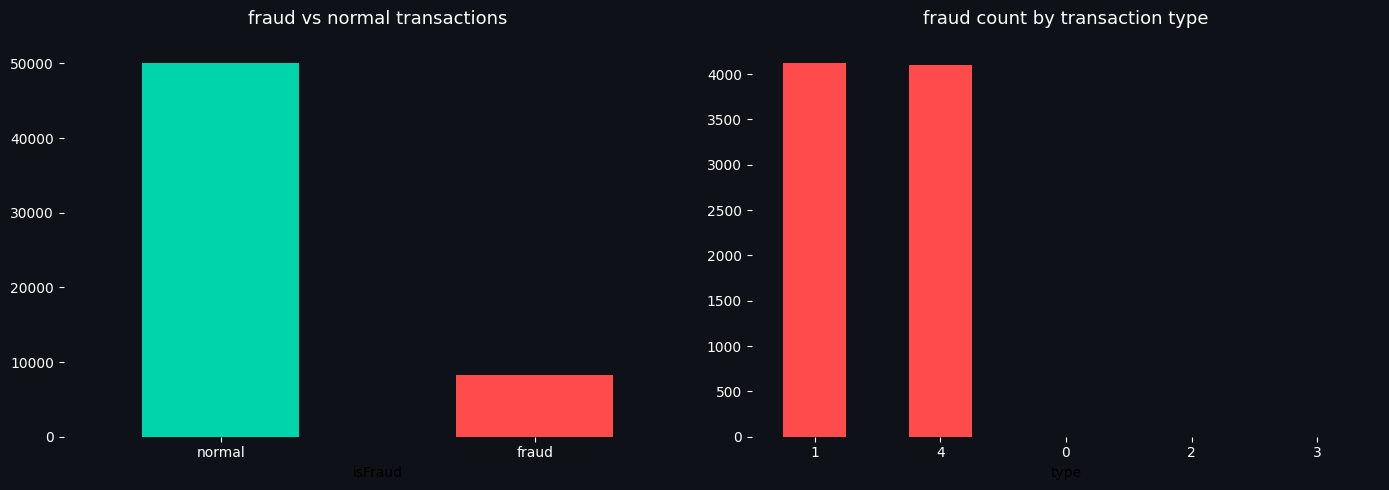

chart saved to reports folder!


In [21]:
# ============================================
# Visualize fraud distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0e1117')

# plot 1 — fraud vs normal
axes[0].set_facecolor('#0e1117')
colors = ['#00d4aa', '#ff4b4b']
df['isFraud'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='none',
    width=0.5
)
axes[0].set_title('fraud vs normal transactions',
                   color='white', pad=15, fontsize=13)
axes[0].set_xticklabels(['normal', 'fraud'],
                          rotation=0, color='white')
axes[0].tick_params(colors='white')
axes[0].spines[['top','right','left','bottom']].set_visible(False)
axes[0].set_facecolor('#0e1117')
for spine in axes[0].spines.values():
    spine.set_visible(False)

# plot 2 — fraud by transaction type
axes[1].set_facecolor('#0e1117')
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
fraud_by_type.plot(
    kind='bar',
    ax=axes[1],
    color='#ff4b4b',
    edgecolor='none',
    width=0.5
)
axes[1].set_title('fraud count by transaction type',
                   color='white', pad=15, fontsize=13)
axes[1].tick_params(colors='white', rotation=0)
axes[1].spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/fraud_distribution.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='#0e1117')
plt.show()
print("chart saved to reports folder!")

In [22]:
# ── dark professional theme for all charts ──────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0e1117',
    'axes.facecolor':    '#0e1117',
    'axes.edgecolor':    '#2d2d2d',
    'axes.labelcolor':   '#e0e0e0',
    'text.color':        '#e0e0e0',
    'xtick.color':       '#a0a0a0',
    'ytick.color':       '#a0a0a0',
    'grid.color':        '#2d2d2d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

FRAUD_COLOR  = '#ff4b4b'
NORMAL_COLOR = '#00d4aa'
ACCENT_COLOR = '#7c6fe0'

print(f"dataset loaded: {df.shape}")
print(f"fraud cases: {df['isFraud'].sum():,}")
print(f"normal cases: {(df['isFraud']==0).sum():,}")
print(f"\ncolumns: {df.columns.tolist()}")

dataset loaded: (58213, 13)
fraud cases: 8,213
normal cases: 50,000

columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'balance_diff_orig', 'balance_diff_dest', 'orig_balance_zero', 'dest_balance_zero', 'amount_to_balance_ratio']


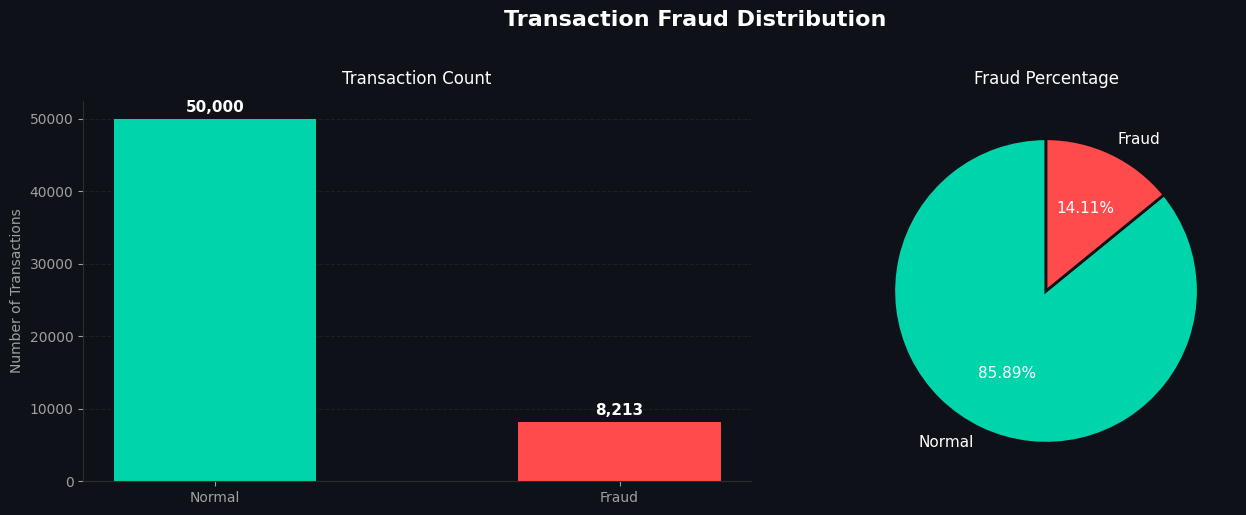

saved: 01_fraud_distribution.png


In [23]:
# ============================================================
# Chart 1: Fraud vs Normal Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Fraud Distribution', 
             fontsize=16, fontweight='bold', 
             color='white', y=1.02)

# ── left: bar chart ─────────────────────────────────────────
counts = df['isFraud'].value_counts()
bars = axes[0].bar(
    ['Normal', 'Fraud'],
    counts.values,
    color=[NORMAL_COLOR, FRAUD_COLOR],
    width=0.5,
    edgecolor='none'
)

# add value labels on top of bars
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{val:,}',
        ha='center', va='bottom',
        color='white', fontsize=11, fontweight='bold'
    )

axes[0].set_title('Transaction Count', color='white', pad=12)
axes[0].set_ylabel('Number of Transactions', color='#a0a0a0')
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

# ── right: pie chart ────────────────────────────────────────
percentages = df['isFraud'].value_counts(normalize=True) * 100
axes[1].pie(
    percentages.values,
    labels=['Normal', 'Fraud'],
    colors=[NORMAL_COLOR, FRAUD_COLOR],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0e1117', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 11}
)
axes[1].set_title('Fraud Percentage', color='white', pad=12)

plt.tight_layout()
plt.savefig('/Users/aadesh/finance-analyzer/reports/01_fraud_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("saved: 01_fraud_distribution.png")



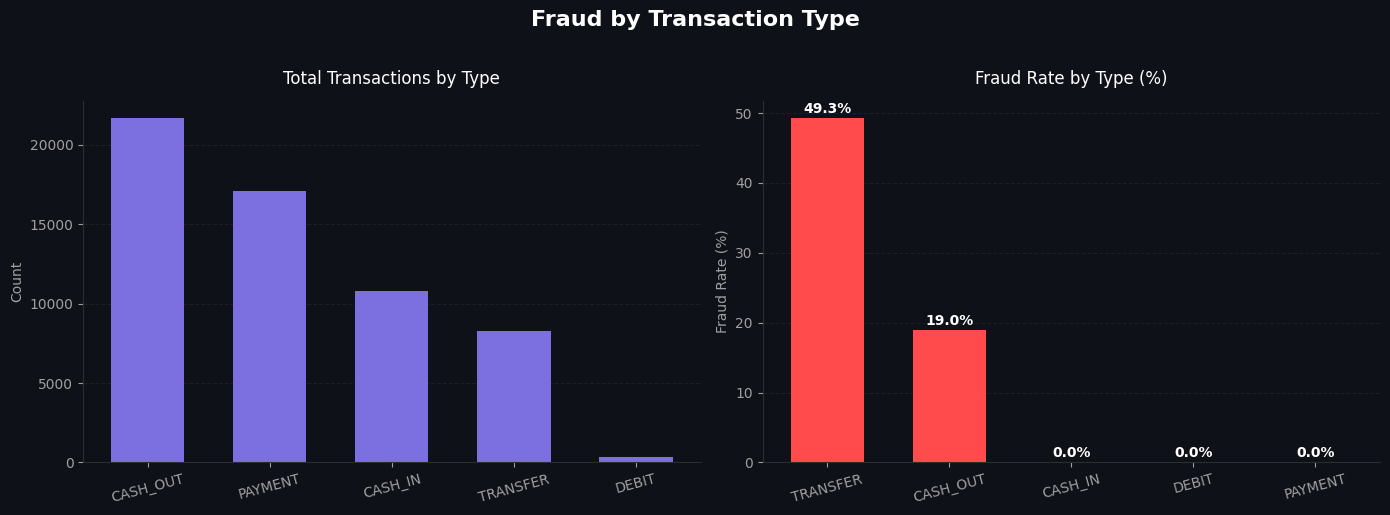

saved: 02_fraud_by_type.png


In [24]:
# ============================================================
# Chart 2: Fraud by Transaction Type
# ============================================================

# decode type numbers back to names for readability
type_map = {0:'CASH_IN', 1:'CASH_OUT', 2:'DEBIT', 
            3:'PAYMENT', 4:'TRANSFER'}
df['type_name'] = df['type'].map(type_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud by Transaction Type', 
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── left: total transactions per type ───────────────────────
type_counts = df['type_name'].value_counts()
bars = axes[0].bar(
    type_counts.index,
    type_counts.values,
    color=ACCENT_COLOR,
    edgecolor='none',
    width=0.6
)
axes[0].set_title('Total Transactions by Type', color='white', pad=12)
axes[0].set_ylabel('Count', color='#a0a0a0')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

# ── right: fraud rate per type ──────────────────────────────
fraud_rate = df.groupby('type_name')['isFraud'].mean() * 100
fraud_rate = fraud_rate.sort_values(ascending=False)

bars2 = axes[1].bar(
    fraud_rate.index,
    fraud_rate.values,
    color=[FRAUD_COLOR if v > 0 else NORMAL_COLOR 
           for v in fraud_rate.values],
    edgecolor='none',
    width=0.6
)

for bar, val in zip(bars2, fraud_rate.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom',
        color='white', fontsize=10, fontweight='bold'
    )

axes[1].set_title('Fraud Rate by Type (%)', color='white', pad=12)
axes[1].set_ylabel('Fraud Rate (%)', color='#a0a0a0')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('/Users/aadesh/finance-analyzer/reports/02_fraud_by_type.png',
            dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("saved: 02_fraud_by_type.png")

/var/folders/50/mywxkk4j6tlb5jl3jqz444fc0000gn/T/ipykernel_35660/1489030228.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


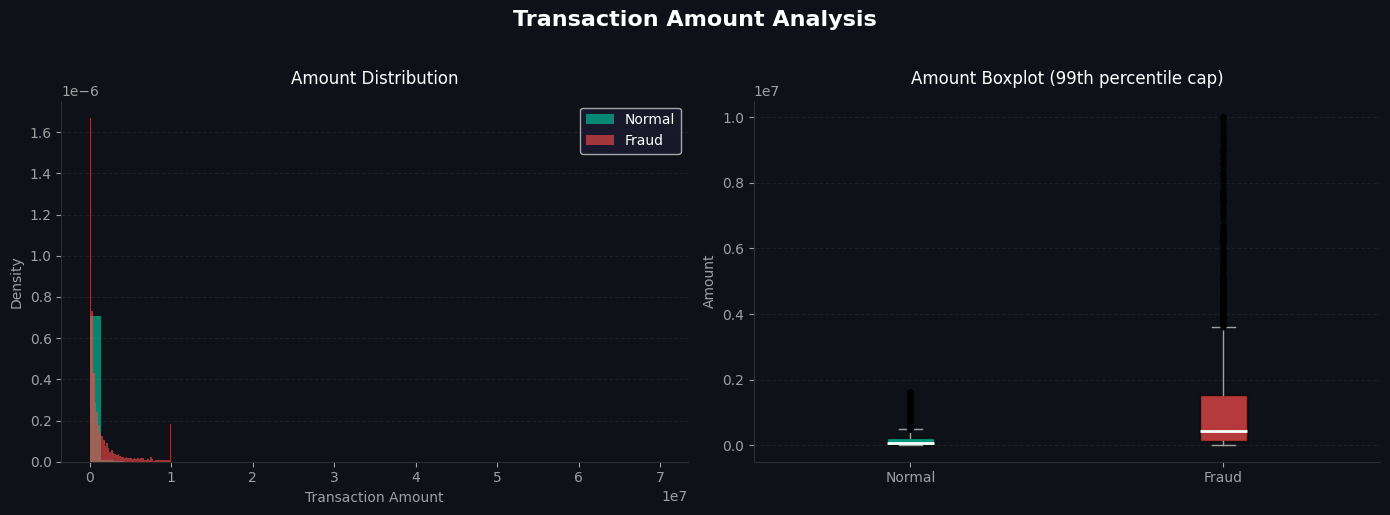

saved: 03_amount_distribution.png


In [25]:
# ============================================================
# Chart 3: Transaction Amount Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Amount Analysis', 
             fontsize=16, fontweight='bold', color='white', y=1.02)

fraud   = df[df['isFraud'] == 1]['amount']
normal  = df[df['isFraud'] == 0]['amount']

# ── left: histogram overlay ─────────────────────────────────
axes[0].hist(normal, bins=50, color=NORMAL_COLOR, 
             alpha=0.6, label='Normal', density=True)
axes[0].hist(fraud,  bins=50, color=FRAUD_COLOR,  
             alpha=0.6, label='Fraud',  density=True)
axes[0].set_title('Amount Distribution', color='white', pad=12)
axes[0].set_xlabel('Transaction Amount', color='#a0a0a0')
axes[0].set_ylabel('Density', color='#a0a0a0')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

# ── right: boxplot comparison ───────────────────────────────
data_to_plot = [normal.clip(upper=normal.quantile(0.99)),
                fraud.clip(upper=fraud.quantile(0.99))]

bp = axes[1].boxplot(
    data_to_plot,
    labels=['Normal', 'Fraud'],
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2},
    whiskerprops={'color': '#a0a0a0'},
    capprops={'color': '#a0a0a0'},
    flierprops={'marker': 'o', 'markersize': 3, 
                'alpha': 0.3, 'color': '#a0a0a0'}
)

bp['boxes'][0].set_facecolor(NORMAL_COLOR)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(FRAUD_COLOR)
bp['boxes'][1].set_alpha(0.7)

axes[1].set_title('Amount Boxplot (99th percentile cap)', 
                   color='white', pad=12)
axes[1].set_ylabel('Amount', color='#a0a0a0')
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('/Users/aadesh/finance-analyzer/reports/03_amount_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("saved: 03_amount_distribution.png")

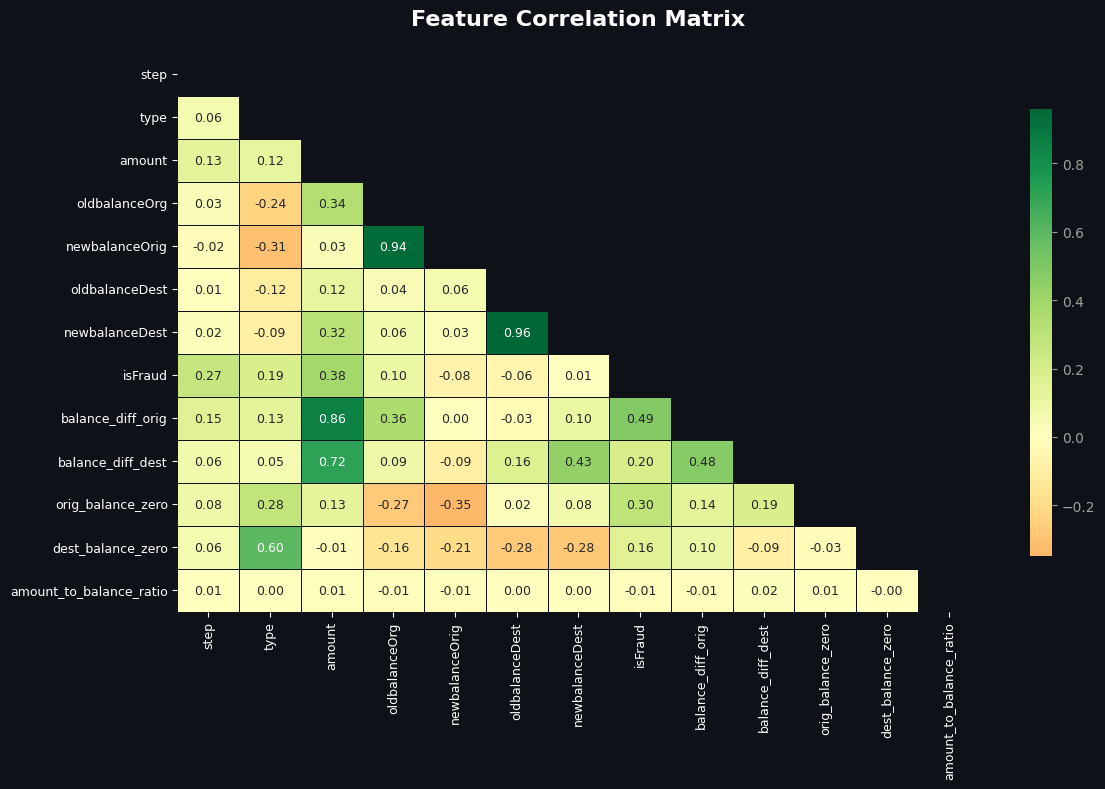

saved: 04_correlation_heatmap.png


In [26]:
# ============================================================
# Chart 4: Correlation Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

# drop type_name column for correlation (it's text)
numeric_df = df.drop(columns=['type_name'])

corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax,
    linewidths=0.5,
    linecolor='#0e1117',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Feature Correlation Matrix', 
             fontsize=16, fontweight='bold', 
             color='white', pad=20)
ax.tick_params(colors='white', labelsize=9)

plt.tight_layout()
plt.savefig('/Users/aadesh/finance-analyzer/reports/04_correlation_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("saved: 04_correlation_heatmap.png")

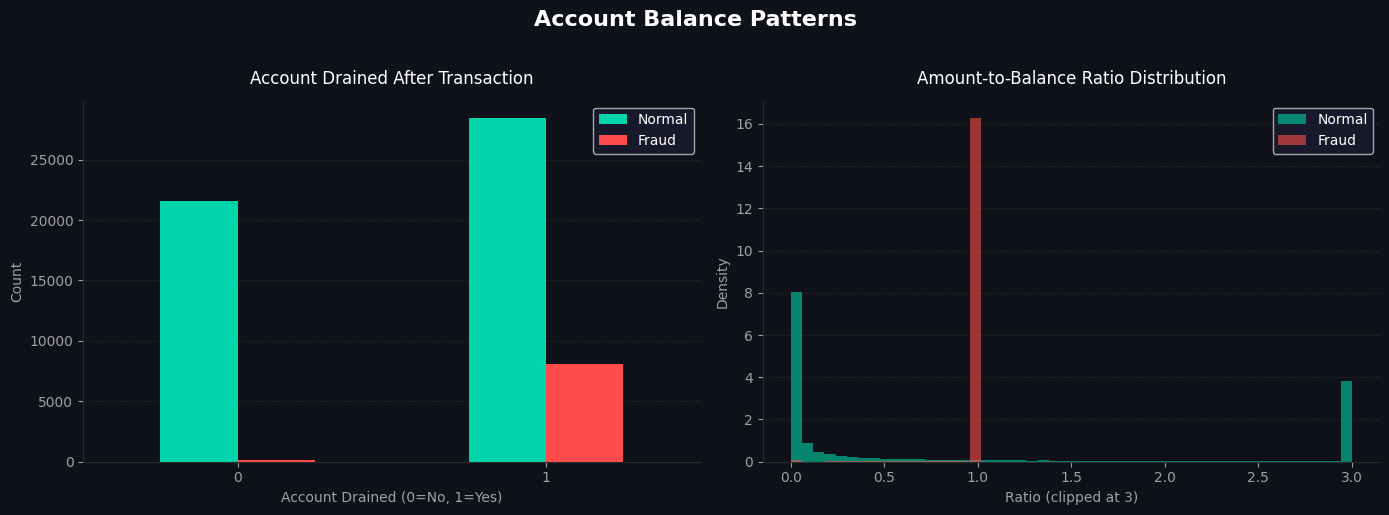

saved: 05_balance_patterns.png


In [27]:
# ============================================================
# Chart 5: Balance Drain Patterns — key fraud signal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Account Balance Patterns', 
             fontsize=16, fontweight='bold', color='white', y=1.02)

# ── left: orig_balance_zero by fraud ────────────────────────
zero_bal = df.groupby(['orig_balance_zero', 'isFraud']).size().unstack()
zero_bal.plot(
    kind='bar',
    ax=axes[0],
    color=[NORMAL_COLOR, FRAUD_COLOR],
    edgecolor='none',
    width=0.5
)
axes[0].set_title('Account Drained After Transaction', 
                   color='white', pad=12)
axes[0].set_xlabel('Account Drained (0=No, 1=Yes)', color='#a0a0a0')
axes[0].set_ylabel('Count', color='#a0a0a0')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Normal', 'Fraud'], 
                facecolor='#1a1a2e', labelcolor='white')
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

# ── right: amount to balance ratio ──────────────────────────
fraud_ratio   = df[df['isFraud']==1]['amount_to_balance_ratio'].clip(upper=3)
normal_ratio  = df[df['isFraud']==0]['amount_to_balance_ratio'].clip(upper=3)

axes[1].hist(normal_ratio, bins=50, color=NORMAL_COLOR, 
             alpha=0.6, label='Normal', density=True)
axes[1].hist(fraud_ratio,  bins=50, color=FRAUD_COLOR,  
             alpha=0.6, label='Fraud',  density=True)
axes[1].set_title('Amount-to-Balance Ratio Distribution', 
                   color='white', pad=12)
axes[1].set_xlabel('Ratio (clipped at 3)', color='#a0a0a0')
axes[1].set_ylabel('Density', color='#a0a0a0')
axes[1].legend(facecolor='#1a1a2e', labelcolor='white')
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('/Users/aadesh/finance-analyzer/reports/05_balance_patterns.png',
            dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("saved: 05_balance_patterns.png")